<a href="https://colab.research.google.com/github/yjkang0240-byte/manufacturingAI/blob/main/wm_811k_wafermap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**This notebook shows how machine learning techniques  can apply in Semi-conductor Industry.**

**Our Objective:** To identify different types of wafer map failure pattern automatically instead of manual work, so that the semi-conductor fabrication can improve on the yield of wafers manufacturing process.

Here, we list all reference:

[1]Wafer Map Failure Pattern Recognition and Similarity Ranking for Large-Scale Data Sets [paper downloas link](http://ieeexplore.ieee.org/document/6932449/)

[2]Wafer Defect Patterns Recognition Based on OPTICS and Multi-Label Classification [paper download link](http://ieeexplore.ieee.org/document/7867343/)

**Step1:  Define your problem**

* **Input:** WM-811K dataset provided by *[MIR lab]*(http://mirlab.org/dataSet/public/).

  *(For convenience, I have converted the original (dot)mat file to (dot)pkl file and you may download from this kernel.)*

* **Model:** One-VS-One multi-class SVMs.

* **Output:** Failure pattern labels.

In [7]:
# loading libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
%matplotlib inline

import os
import warnings
warnings.filterwarnings("ignore")

**Step2: Prepare your data**

* **Data Selection & Preprocessing: ** Consider what data is available, what data is missing and what data can be removed. Also, organize your selected data by formatting, cleaning and sampling from it.

Here is a simple **checklist** provided for you to understand your dataset better:

* Data summary
* Target distribution
* Missing value check
* Others

>** Data summary**

In [9]:
import kagglehub
path = kagglehub.dataset_download("qingyi/wm811k-wafer-map")
print(path)  # 여기 찍히는 폴더 안에 LSWMD.pkl 이 있음

100%|██████████| 149M/149M [00:07<00:00, 21.2MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/qingyi/wm811k-wafer-map/versions/1


In [12]:
import kagglehub, pandas as pd, os

# 데이터 폴더 경로 (방금 출력된 것)
path = kagglehub.dataset_download("qingyi/wm811k-wafer-map")
print("폴더:", path)
print("안의 파일:", os.listdir(path))          # LSWMD.pkl 이 보일 거예요

# 실제 pkl 경로로 로드
pkl = os.path.join(path, "LSWMD.pkl")
df = pd.read_pickle(pkl)
df.info()

Using Colab cache for faster access to the 'wm811k-wafer-map' dataset.
폴더: /kaggle/input/wm811k-wafer-map
안의 파일: ['LSWMD.pkl']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   waferIndex      811457 non-null  float64
 4   trianTestLabel  811457 non-null  object 
 5   failureType     811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 37.1+ MB


In [15]:
import pandas as pd, os
path = "/kaggle/input/wm811k-wafer-map"
df = pd.read_pickle(os.path.join(path, "LSWMD.pkl"))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   waferIndex      811457 non-null  float64
 4   trianTestLabel  811457 non-null  object 
 5   failureType     811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 37.1+ MB


In [1]:
# %% [markdown]
# WM-811K 웨이퍼맵 결함 분류 — 실행형 (업로드 노트북 현대화 버전)
#
# 원본 Kaggle 노트북(theano/keras/구 sklearn·skimage)을 **현재 라이브러리에서 그대로 돌아가게** 이식했습니다.
# - 특징 59개: 밀도 13 + 라돈 40 + 기하 6
# - 분류기: OneVsOne LinearSVC (class_weight='balanced')
# - 평가: 정확도 + **macro-F1 + 클래스별 리포트 + 정규화 혼동행렬** (불균형 대응)
#
# 실행 방법
# ```bash
# pip install pandas numpy matplotlib scikit-image scikit-learn scipy
# python3 wm811k_runnable.py --path ./LSWMD.pkl --out ./out   # 실제 데이터
# python3 wm811k_runnable.py --synthetic --out ./out          # 데이터 없이 데모
# ```
# VSCode: 이 파일을 열고 `# %%` 셀 단위로 ▶ 실행하거나, 통합 터미널에서 위 명령 실행.

# %%
import argparse, os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from matplotlib.colors import ListedColormap
from scipy import interpolate
from skimage.transform import radon
from skimage import measure
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsOneClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# 한글 폰트(있으면)
for _c in ["/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
           "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"]:
    if os.path.exists(_c):
        fm.fontManager.addfont(_c); plt.rcParams["font.family"] = fm.FontProperties(fname=_c).get_name(); break
plt.rcParams["axes.unicode_minus"] = False

DEFECTS = ["Center","Donut","Edge-Loc","Edge-Ring","Loc","Random","Scratch","Near-full"]
CMAP = ListedColormap(["#FFFFFF", "#D8E6F2", "#C0392B"])   # 0 밖 / 1 pass / 2 fail

# %%
# ------------------------------------------------------------------ 데이터 로드
def clean_label(x):
    a = np.asarray(x)
    while a.dtype == object and a.size == 1:
        a = np.asarray(a.reshape(-1)[0])
    return str(a.reshape(-1)[0]) if a.size else "unlabeled"

def load_real(path):
    df = pd.read_pickle(path)
    df["ftype"] = df["failureType"].apply(clean_label)
    return df[df["ftype"].isin(DEFECTS)].reset_index(drop=True)   # 8개 결함만

def make_synthetic(n_per=None):
    rng = np.random.default_rng(0); N = 48
    yy, xx = np.mgrid[0:N,0:N]; cy=cx=(N-1)/2; r=np.sqrt((xx-cx)**2+(yy-cy)**2); R=N/2-1
    ang = np.arctan2(yy-cy, xx-cx); mask = r <= R
    def base():
        m=np.zeros((N,N),int); m[mask]=1; m[(rng.random((N,N))<0.02)&mask]=2; return m
    def add(m,c,p): s=c&mask&(rng.random((N,N))<p); m[s]=2; return m
    counts = n_per or {"Edge-Ring":260,"Edge-Loc":200,"Center":170,"Loc":150,
                       "Scratch":110,"Random":90,"Donut":70,"Near-full":50}
    rows=[]
    for cls,n in counts.items():
        for _ in range(n):
            m=base()
            if cls=="Center": m=add(m,r<R*(0.30+rng.random()*0.1),0.9)
            elif cls=="Donut": m=add(m,(r>R*0.45)&(r<R*0.68),0.9)
            elif cls=="Edge-Ring": m=add(m,r>R*0.82,0.92)
            elif cls=="Edge-Loc":
                a0=rng.random()*6.28; m=add(m,(r>R*0.7)&(np.abs(((ang-a0+3.14)%6.28)-3.14)<0.7),0.9)
            elif cls=="Loc":
                lx,ly=cx+(rng.random()-0.5)*R,cy+(rng.random()-0.5)*R
                m=add(m,np.sqrt((xx-lx)**2+(yy-ly)**2)<R*0.28,0.9)
            elif cls=="Random": m=add(m,rng.random((N,N))<0.12,1.0)
            elif cls=="Scratch":
                a0=rng.random()*3.14
                for t in np.linspace(0,1,200):
                    sx=int(cx+(t-.5)*2*R*.9*np.cos(a0)); sy=int(cy+(t-.5)*2*R*.9*np.sin(a0))
                    if 0<=sx<N and 0<=sy<N and mask[sy,sx]: m[sy,sx]=2
            elif cls=="Near-full": m=add(m,r<R*0.95,0.9)
            rows.append({"waferMap":m,"ftype":cls})
    return pd.DataFrame(rows)

# %%
# ------------------------------------------------------------------ 특징 59개
def fea_density(x):                       # 13
    rows, cols = x.shape
    br = np.linspace(0, rows, 6).astype(int); bc = np.linspace(0, cols, 6).astype(int)
    regs = [x[br[0]:br[1], :], x[:, bc[4]:bc[5]], x[br[4]:br[5], :], x[:, bc[0]:bc[1]]]
    for i in range(1,4):
        for j in range(1,4):
            regs.append(x[br[i]:br[i+1], bc[j]:bc[j+1]])
    return [100*np.sum(rg==2)/np.size(rg) if np.size(rg) else 0.0 for rg in regs]

def _interp20(v):
    if v.size < 4: v = np.pad(v, (0, 4-v.size))
    xs = np.linspace(1, v.size, v.size)
    f = interpolate.interp1d(xs, v, kind="cubic")
    return f(np.linspace(1, v.size, 20))

def fea_radon(x):                          # 40 (mean 20 + std 20)
    img = (x == 2).astype(float)
    theta = np.linspace(0., 180., max(img.shape), endpoint=False)
    sino = radon(img, theta=theta, circle=False)
    return np.concatenate([_interp20(np.mean(sino, axis=1))/100.0,
                           _interp20(np.std(sino, axis=1))/100.0])

def fea_geom(x):                           # 6
    img = (x == 2).astype(int)
    lab = measure.label(img, connectivity=1)
    props = measure.regionprops(lab)
    if not props:
        return [0.0]*6
    p = max(props, key=lambda pr: pr.area)
    H, W = x.shape
    return [p.area/(H*W), p.perimeter/np.sqrt(H**2+W**2),
            p.major_axis_length/np.sqrt(H**2+W**2),
            p.minor_axis_length/np.sqrt(H**2+W**2),
            p.eccentricity, p.solidity]

def extract(w):
    x = np.asarray(w)
    return np.array(fea_density(x) + list(fea_radon(x)) + fea_geom(x))  # 59

# %%
# ------------------------------------------------------------------ 메인
def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--path"); ap.add_argument("--synthetic", action="store_true")
    ap.add_argument("--out", default="./out")
    args, _ = ap.parse_known_args()
    os.makedirs(args.out, exist_ok=True)
    SYN = (args.path is None) or args.synthetic
    tag = "[합성 데모]" if SYN else "[실데이터]"
    df = make_synthetic() if SYN else load_real(args.path)
    print(f"{tag} 결함 웨이퍼 수: {len(df)}")
    print(df["ftype"].value_counts().to_string())

    # 클래스 분포
    vc = df["ftype"].value_counts().reindex(DEFECTS)
    plt.figure(figsize=(10,4)); plt.bar(vc.index, vc.values, color="#7F77DD")
    plt.yscale("log"); plt.title(f"8개 결함 분포 {tag}"); plt.xticks(rotation=20)
    plt.tight_layout(); plt.savefig(f"{args.out}/01_distribution.png", dpi=120); plt.close()

    # 특징 추출
    print("특징 추출 중(라돈 포함, 다소 시간 소요)...")
    X = np.vstack(df["waferMap"].apply(extract).values)
    y = df["ftype"].values
    print("특징 행렬:", X.shape, "(웨이퍼 × 59)")

    Xs = StandardScaler().fit_transform(X)
    Xtr, Xte, ytr, yte = train_test_split(Xs, y, test_size=0.25, random_state=42, stratify=y)
    clf = OneVsOneClassifier(LinearSVC(class_weight="balanced", random_state=42, dual="auto"))
    clf.fit(Xtr, ytr)
    yp = clf.predict(Xte)

    acc = accuracy_score(yte, yp); mf1 = f1_score(yte, yp, average="macro")
    print(f"\n=== 결과 {tag} ===")
    print(f"정확도(accuracy) : {acc*100:.2f}%")
    print(f"macro-F1        : {mf1:.3f}   <- 불균형에선 이 지표를 봐야 함")
    print("\n클래스별 리포트:\n", classification_report(yte, yp, labels=DEFECTS, zero_division=0))

    cm = confusion_matrix(yte, yp, labels=DEFECTS)
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    ConfusionMatrixDisplay(cm, display_labels=DEFECTS).plot(ax=ax[0], cmap="Blues", colorbar=False, xticks_rotation=45)
    ax[0].set_title("혼동행렬 (개수)")
    cmn = cm.astype(float)/cm.sum(axis=1, keepdims=True).clip(min=1)
    ConfusionMatrixDisplay(cmn, display_labels=DEFECTS).plot(ax=ax[1], cmap="Blues", colorbar=False, xticks_rotation=45, values_format=".2f")
    ax[1].set_title("정규화 혼동행렬 (행=실제)")
    fig.suptitle(f"분류 결과 {tag}  acc={acc*100:.1f}%  macro-F1={mf1:.3f}", fontsize=13)
    plt.tight_layout(); plt.savefig(f"{args.out}/02_confusion.png", dpi=120); plt.close()
    print(f"\n그림 저장: {args.out}/01_distribution.png, {args.out}/02_confusion.png")

if __name__ == "__main__":
    main()

[합성 데모] 결함 웨이퍼 수: 1100
ftype
Edge-Ring    260
Edge-Loc     200
Center       170
Loc          150
Scratch      110
Random        90
Donut         70
Near-full     50


/tmp/ipykernel_16402/4065451951.py:149: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(f"{args.out}/01_distribution.png", dpi=120); plt.close()
/tmp/ipykernel_16402/4065451951.py:149: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(f"{args.out}/01_distribution.png", dpi=120); plt.close()
/tmp/ipykernel_16402/4065451951.py:149: UserWarning: Glyph 54632 (\N{HANGUL SYLLABLE HAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(f"{args.out}/01_distribution.png", dpi=120); plt.close()
/tmp/ipykernel_16402/4065451951.py:149: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(f"{args.out}/01_distribution.png", dpi=120); plt.close()
/tmp/ipykernel_16402/4065451951.py:149: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tigh

특징 추출 중(라돈 포함, 다소 시간 소요)...
특징 행렬: (1100, 59) (웨이퍼 × 59)

=== 결과 [합성 데모] ===
정확도(accuracy) : 100.00%
macro-F1        : 1.000   <- 불균형에선 이 지표를 봐야 함

클래스별 리포트:
               precision    recall  f1-score   support

      Center       1.00      1.00      1.00        42
       Donut       1.00      1.00      1.00        18
    Edge-Loc       1.00      1.00      1.00        50
   Edge-Ring       1.00      1.00      1.00        65
         Loc       1.00      1.00      1.00        38
      Random       1.00      1.00      1.00        23
     Scratch       1.00      1.00      1.00        27
   Near-full       1.00      1.00      1.00        12

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275



/tmp/ipykernel_16402/4065451951.py:177: UserWarning: Glyph 54844 (\N{HANGUL SYLLABLE HON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(f"{args.out}/02_confusion.png", dpi=120); plt.close()
/tmp/ipykernel_16402/4065451951.py:177: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(f"{args.out}/02_confusion.png", dpi=120); plt.close()
/tmp/ipykernel_16402/4065451951.py:177: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(f"{args.out}/02_confusion.png", dpi=120); plt.close()
/tmp/ipykernel_16402/4065451951.py:177: UserWarning: Glyph 47148 (\N{HANGUL SYLLABLE RYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(f"{args.out}/02_confusion.png", dpi=120); plt.close()
/tmp/ipykernel_16402/4065451951.py:177: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout


그림 저장: ./out/01_distribution.png, ./out/02_confusion.png


In [2]:
from google.colab import files
files.upload()   # 창이 뜨면 wm811k_runnable.py 선택

KeyboardInterrupt: 

In [2]:
%%writefile wm811k_runnable.py
import argparse, os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy import interpolate
from skimage.transform import radon
from skimage import measure
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsOneClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

plt.rcParams["axes.unicode_minus"] = False
DEFECTS = ["Center","Donut","Edge-Loc","Edge-Ring","Loc","Random","Scratch","Near-full"]

def clean_label(x):
    a = np.asarray(x)
    while a.dtype == object and a.size == 1:
        a = np.asarray(a.reshape(-1)[0])
    return str(a.reshape(-1)[0]) if a.size else "unlabeled"

def load_real(path):
    df = pd.read_pickle(path)
    df["ftype"] = df["failureType"].apply(clean_label)
    return df[df["ftype"].isin(DEFECTS)].reset_index(drop=True)

def fea_density(x):
    rows, cols = x.shape
    br = np.linspace(0, rows, 6).astype(int); bc = np.linspace(0, cols, 6).astype(int)
    regs = [x[br[0]:br[1], :], x[:, bc[4]:bc[5]], x[br[4]:br[5], :], x[:, bc[0]:bc[1]]]
    for i in range(1,4):
        for j in range(1,4):
            regs.append(x[br[i]:br[i+1], bc[j]:bc[j+1]])
    return [100*np.sum(rg==2)/np.size(rg) if np.size(rg) else 0.0 for rg in regs]

def _interp20(v):
    if v.size < 4: v = np.pad(v, (0, 4-v.size))
    xs = np.linspace(1, v.size, v.size)
    f = interpolate.interp1d(xs, v, kind="cubic")
    return f(np.linspace(1, v.size, 20))

def fea_radon(x):
    img = (x == 2).astype(float)
    theta = np.linspace(0., 180., max(img.shape), endpoint=False)
    sino = radon(img, theta=theta, circle=False)
    return np.concatenate([_interp20(np.mean(sino, axis=1))/100.0,
                           _interp20(np.std(sino, axis=1))/100.0])

def fea_geom(x):
    img = (x == 2).astype(int)
    lab = measure.label(img, connectivity=1)
    props = measure.regionprops(lab)
    if not props: return [0.0]*6
    p = max(props, key=lambda pr: pr.area); H, W = x.shape
    return [p.area/(H*W), p.perimeter/np.sqrt(H**2+W**2),
            p.major_axis_length/np.sqrt(H**2+W**2),
            p.minor_axis_length/np.sqrt(H**2+W**2), p.eccentricity, p.solidity]

def extract(w):
    x = np.asarray(w)
    return np.array(fea_density(x) + list(fea_radon(x)) + fea_geom(x))

def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--path", required=True); ap.add_argument("--out", default="./out")
    args, _ = ap.parse_known_args(); os.makedirs(args.out, exist_ok=True)
    df = load_real(args.path)
    print("결함 웨이퍼 수:", len(df)); print(df["ftype"].value_counts().to_string())

    vc = df["ftype"].value_counts().reindex(DEFECTS)
    plt.figure(figsize=(10,4)); plt.bar(vc.index, vc.values, color="#7F77DD")
    plt.yscale("log"); plt.title("8 defect distribution"); plt.xticks(rotation=20)
    plt.tight_layout(); plt.savefig(f"{args.out}/01_distribution.png", dpi=120); plt.close()

    print("특징 추출 중(라돈 포함, 다소 시간 소요)...")
    X = np.vstack(df["waferMap"].apply(extract).values); y = df["ftype"].values
    print("특징 행렬:", X.shape)
    Xs = StandardScaler().fit_transform(X)
    Xtr, Xte, ytr, yte = train_test_split(Xs, y, test_size=0.25, random_state=42, stratify=y)
    clf = OneVsOneClassifier(LinearSVC(class_weight="balanced", random_state=42, dual="auto"))
    clf.fit(Xtr, ytr); yp = clf.predict(Xte)

    acc = accuracy_score(yte, yp); mf1 = f1_score(yte, yp, average="macro")
    print(f"\n정확도: {acc*100:.2f}%   macro-F1: {mf1:.3f}")
    print("\n클래스별 리포트:\n", classification_report(yte, yp, labels=DEFECTS, zero_division=0))

    cm = confusion_matrix(yte, yp, labels=DEFECTS)
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    ConfusionMatrixDisplay(cm, display_labels=DEFECTS).plot(ax=ax[0], cmap="Blues", colorbar=False, xticks_rotation=45)
    ax[0].set_title("Confusion (count)")
    cmn = cm.astype(float)/cm.sum(axis=1, keepdims=True).clip(min=1)
    ConfusionMatrixDisplay(cmn, display_labels=DEFECTS).plot(ax=ax[1], cmap="Blues", colorbar=False, xticks_rotation=45, values_format=".2f")
    ax[1].set_title("Confusion (normalized)")
    fig.suptitle(f"acc={acc*100:.1f}%  macro-F1={mf1:.3f}"); plt.tight_layout()
    plt.savefig(f"{args.out}/02_confusion.png", dpi=120); plt.close()
    print(f"\n그림 저장: {args.out}/01_distribution.png, {args.out}/02_confusion.png")

if __name__ == "__main__":
    main()

Writing wm811k_runnable.py


In [1]:
!ls -la wm811k_runnable.py
!python wm811k_runnable.py --path /kaggle/input/wm811k-wafer-map/LSWMD.pkl --out ./out

-rw-r--r-- 1 root root 4641 Jul  2 06:10 wm811k_runnable.py
결함 웨이퍼 수: 25519
ftype
Edge-Ring    9680
Edge-Loc     5189
Center       4294
Loc          3593
Scratch      1193
Random        866
Donut         555
Near-full     149
특징 추출 중(라돈 포함, 다소 시간 소요)...
특징 행렬: (25519, 59)

정확도: 87.99%   macro-F1: 0.844

클래스별 리포트:
               precision    recall  f1-score   support

      Center       0.95      0.96      0.96      1074
       Donut       0.78      0.85      0.81       139
    Edge-Loc       0.82      0.79      0.80      1297
   Edge-Ring       0.98      0.96      0.97      2420
         Loc       0.79      0.71      0.75       898
      Random       0.82      0.94      0.87       217
     Scratch       0.56      0.82      0.67       298
   Near-full       0.88      0.97      0.92        37

    accuracy                           0.88      6380
   macro avg       0.82      0.87      0.84      6380
weighted avg       0.89      0.88      0.88      6380


그림 저장: ./out/01_distribution.png

In [3]:
import pandas as pd, numpy as np
df = pd.read_pickle("/kaggle/input/wm811k-wafer-map/LSWMD.pkl")
# ... 뒷부분 생략 ...

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   waferIndex      811457 non-null  float64
 4   trianTestLabel  811457 non-null  object 
 5   failureType     811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 37.1+ MB


* The dataset comprises **811,457 wafer maps**, along with additional information such as **wafer die size**, **lot name** and **wafer index**.

* The training / test set were already split by domain experts, but in this kernel we ignore this info and we re-divided the dataset into training set and test set by hold-out mehtod which will be introduced in later section.

>Target distribution

In [5]:
import pandas as pd, numpy as np
df = pd.read_pickle("/kaggle/input/wm811k-wafer-map/LSWMD.pkl")
df["ft"] = df["failureType"].apply(lambda x: str(np.asarray(x).reshape(-1)[0]) if np.asarray(x).size else "")
small = df[df["ft"].isin(["Center","Donut","Edge-Loc","Edge-Ring","Loc","Random","Scratch","Near-full"])].groupby("ft").head(150)
small.to_pickle("LSWMD_small.pkl")
print(small["ft"].value_counts())

ft
Loc          150
Edge-Loc     150
Center       150
Edge-Ring    150
Scratch      150
Random       150
Donut        150
Near-full    149
Name: count, dtype: int64


In [6]:
df.tail()

,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType,ft
811452,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,...",600.0,lot47542,23.0,[[Test]],[[Edge-Ring]],Edge-Ring
811453,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 1, 1,...",600.0,lot47542,24.0,[[Test]],[[Edge-Loc]],Edge-Loc
811454,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,...",600.0,lot47542,25.0,[[Test]],[[Edge-Ring]],Edge-Ring
811455,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,...",600.0,lot47543,1.0,[],[],
811456,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,...",600.0,lot47543,2.0,[],[],


* The dataset were collected from **47,543 lots** in real-world fab. However, **47,543 lots x 25 wafer/lot =1,157,325 wafer maps ** is larger than **811,457 wafer maps**.

* Let's see what happened.

In [7]:
# 라벨 결측 파악
import numpy as np, pandas as pd
df = pd.read_pickle("/kaggle/input/wm811k-wafer-map/LSWMD.pkl")
print("전체 행:", len(df), "| 컬럼:", list(df.columns))

def flat(x):                       # 빈 배열이면 None(=결측)으로
    a = np.asarray(x)
    while a.dtype == object and a.size == 1: a = np.asarray(a.reshape(-1)[0])
    return str(a.reshape(-1)[0]) if a.size else None

df["ftype"] = df["failureType"].apply(flat)
n = len(df); lab = df["ftype"].notna().sum()
print(f"라벨 있음: {lab:,} ({100*lab/n:.1f}%)  |  미라벨(결측): {n-lab:,} ({100*(n-lab)/n:.1f}%)")
print(df["ftype"].value_counts(dropna=False))

전체 행: 811457 | 컬럼: ['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType']
라벨 있음: 172,950 (21.3%)  |  미라벨(결측): 638,507 (78.7%)
ftype
None         638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


**시각화** 라벨 결측 비율 — 지도학습에 쓸 데이터가 얼마나 되는지.

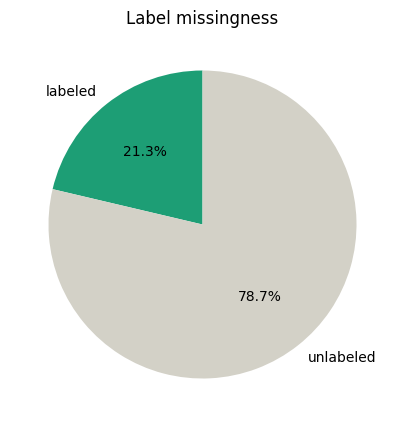

In [14]:
import matplotlib.pyplot as plt
lab = df["ftype"].notna().sum()
plt.figure(figsize=(5,5))
plt.pie([lab, len(df)-lab], labels=["labeled","unlabeled"], autopct="%1.1f%%",
        colors=["#1D9E75","#D3D1C7"], startangle=90); plt.title("Label missingness"); plt.show()

약 21% vs 79%. 라벨이 귀해서 증강·준지도가 필요하다는 근거.

In [16]:
df["dim"]  = df["waferMap"].apply(lambda w: np.asarray(w).shape)      # 맵 크기
df["ndie"] = df["waferMap"].apply(lambda w: int((np.asarray(w) > 0).sum()))  # 다이 개수
print("die 0개인 맵:", (df["ndie"]==0).sum(), "| 아주 작은 맵(<5):", df["dim"].apply(lambda d: min(d)<5).sum())

DEFECTS = ["Center","Donut","Edge-Loc","Edge-Ring","Loc","Random","Scratch","Near-full"]
df_labeled = df[df["ftype"].notna()].copy()                          # 라벨 전체(9클래스)
df_defect  = df[df["ftype"].isin(DEFECTS)].copy()
df_defect  = df_defect[(df_defect["ndie"]>0) & (df_defect["dim"].apply(lambda d: min(d)>=5))].reset_index(drop=True)
print("라벨 전체:", len(df_labeled), "| 결함8(정제 후):", len(df_defect))

die 0개인 맵: 0 | 아주 작은 맵(<5): 2
라벨 전체: 172950 | 결함8(정제 후): 25519


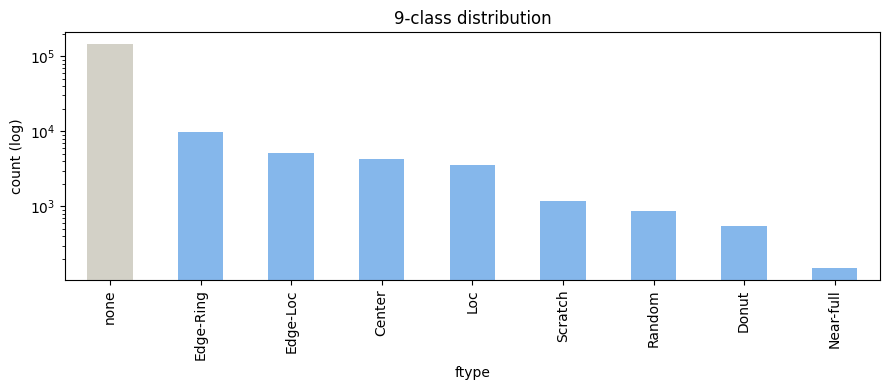

ftype
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [17]:
vc = df_labeled["ftype"].value_counts()
plt.figure(figsize=(9,4))
vc.plot(kind="bar", color=["#D3D1C7" if k=="none" else "#85B7EB" for k in vc.index])
plt.yscale("log"); plt.ylabel("count (log)"); plt.title("9-class distribution"); plt.tight_layout(); plt.show()
print(vc)

약 21% vs 79%. 라벨이 귀해서 증강·준지도가 필요하다는 근거.

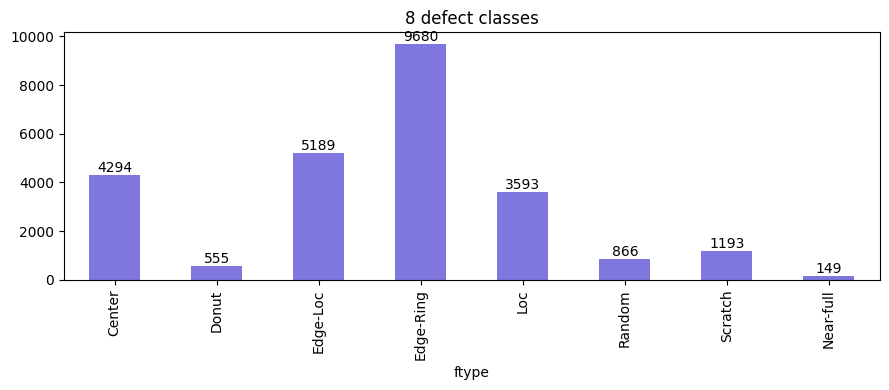

In [20]:
vd = df_defect["ftype"].value_counts().reindex(DEFECTS)
ax = vd.plot(kind="bar", figsize=(9,4), color="#7F77DD")
for i,v in enumerate(vd): ax.text(i, v, f"{v}", ha="center", va="bottom")
plt.title("8 defect classes"); plt.tight_layout(); plt.show()

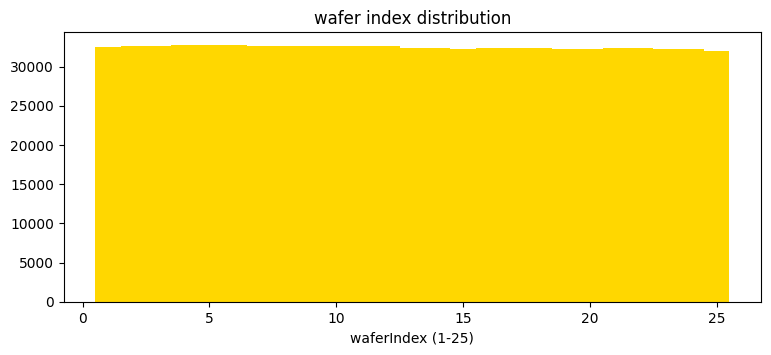

In [23]:
wi = pd.to_numeric(df["waferIndex"], errors="coerce").dropna()
plt.figure(figsize=(9,3.5)); plt.hist(wi, bins=range(1,27), align="left", color="gold")
plt.xlabel("waferIndex (1-25)"); plt.title("wafer index distribution"); plt.show()

 보통 로트당 25장인데 뒤 번호로 갈수록 줄면 "부분 로트"가 있다는 신호.
 로트를 다 채우지 못한 로트가 있다느 소리

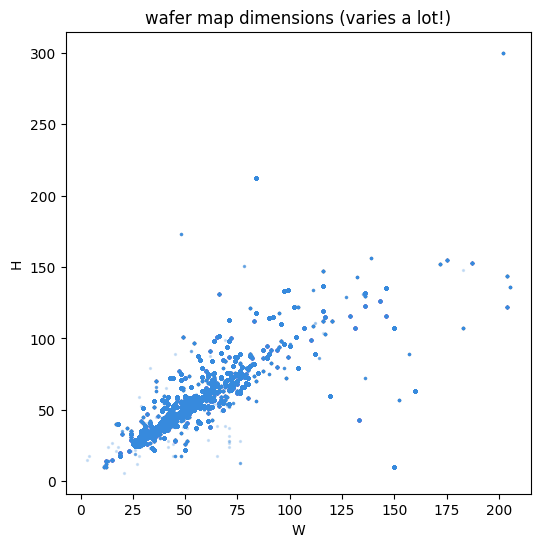

In [24]:
H = df["dim"].apply(lambda d:d[0]); W = df["dim"].apply(lambda d:d[1])
plt.figure(figsize=(6,6)); plt.scatter(W, H, s=2, alpha=0.2, color="#378ADD")
plt.xlabel("W"); plt.ylabel("H"); plt.title("wafer map dimensions (varies a lot!)"); plt.show()

크기가 제각각이라, CNN/VLM에 넣기 전 고정 크기로 리사이즈가 필요하다는 결정적 근거.

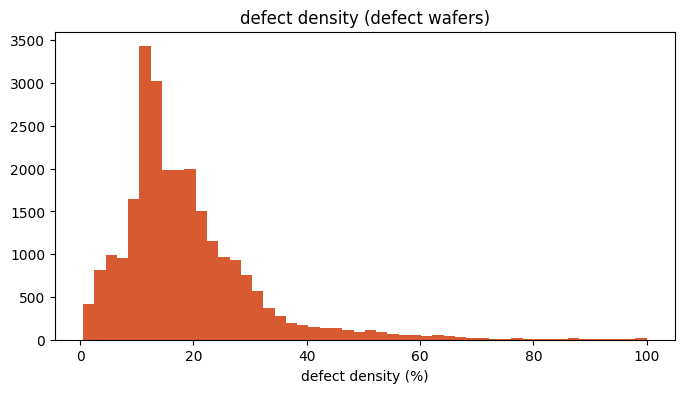

In [25]:
df_defect["density"] = df_defect["waferMap"].apply(
    lambda w: (np.asarray(w)==2).sum()/max((np.asarray(w)>0).sum(),1))
plt.figure(figsize=(8,4)); plt.hist(df_defect["density"]*100, bins=50, color="#D85A30")
plt.xlabel("defect density (%)"); plt.title("defect density (defect wafers)"); plt.show()

 대부분 낮은 밀도에 몰리고 Near-full만 오른쪽 꼬리 → 수율 타격이 큰 결함 구분.

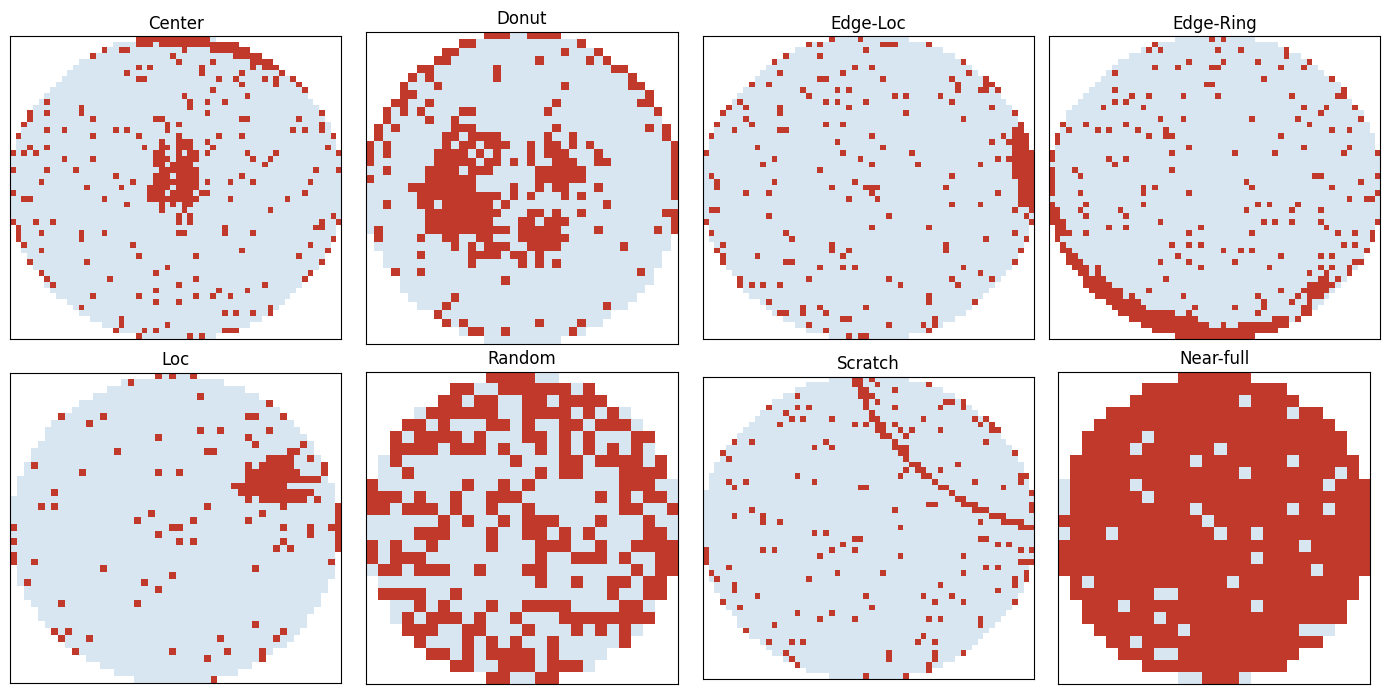

In [26]:
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["#FFFFFF","#D8E6F2","#C0392B"])   # 밖/정상/불량
fig, ax = plt.subplots(2, 4, figsize=(14,7))
for a, cls in zip(ax.ravel(), DEFECTS):
    s = df_defect[df_defect["ftype"]==cls]
    a.set_title(cls); a.set_xticks([]); a.set_yticks([])
    if len(s): a.imshow(np.asarray(s.iloc[0]["waferMap"]), cmap=cmap, vmin=0, vmax=2)
plt.tight_layout(); plt.show()

실제 데이터의 모습- , 전처리(노이즈 제거)가 필요하다는 근거, 크기·모양이 제각각이라는 걸 확인할 수 있음.

In [29]:
import warnings
warnings.filterwarnings("ignore")

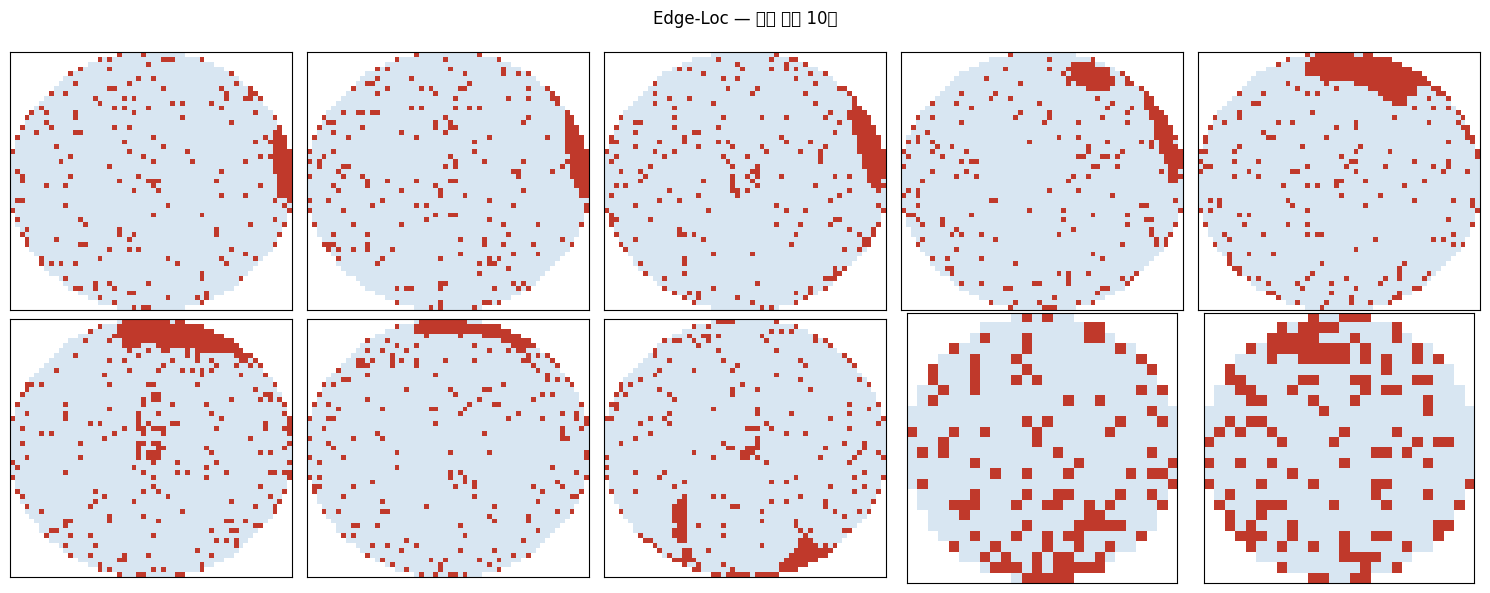

In [30]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["#FFFFFF","#D8E6F2","#C0392B"])
cls = "Edge-Loc"                                   # 보고 싶은 클래스
s = df_defect[df_defect["ftype"]==cls].head(10)
fig, ax = plt.subplots(2, 5, figsize=(15,6))
for a, (_, row) in zip(ax.ravel(), s.iterrows()):
    a.imshow(np.asarray(row["waferMap"]), cmap=cmap, vmin=0, vmax=2)
    a.set_xticks([]); a.set_yticks([])
fig.suptitle(f"{cls} — 실제 샘플 10장"); plt.tight_layout(); plt.show()

none        약 147,000   ← 문자열: 판정 완료, 무결함 (라벨의 85%),
Near-full   약 150,
NaN         약 638,000   ← None(결측): 라벨 자체가 없음 (전체의 79%)

* The figure shows that not all lots have perfect 25 wafer maps and it may caused by **sensor failure** or other unknown problems.

* Fortunately, we do not need wafer index feature in our classification so we can just drop the variable.

In [ ]:
df = df.drop(['waferIndex'], axis = 1)

* We can not get much information from the wafer map column but we can see the die size for each instance is different.

* We create a new variable **'waferMapDim'** for wafer map dim checking.


In [8]:
def find_dim(x):
    dim0=np.size(x,axis=0)
    dim1=np.size(x,axis=1)
    return dim0,dim1
df['waferMapDim']=df.waferMap.apply(find_dim)
df.sample(5)

,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType,ftype,waferMapDim
7264,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1956.0,lot293,11.0,[[Training]],[[Loc]],Loc,"(60, 40)"
475826,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1513.0,lot29364,14.0,[],[],None,"(49, 39)"
767660,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1376.0,lot45759,16.0,[[Test]],[[none]],none,"(44, 41)"
319182,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1534.0,lot19360,18.0,[],[],None,"(45, 43)"
123622,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2,...",515.0,lot8218,14.0,[],[],None,"(25, 27)"


In [9]:
max(df.waferMapDim), min(df.waferMapDim)

((300, 202), (6, 21))

In [10]:
uni_waferDim=np.unique(df.waferMapDim, return_counts=True)
uni_waferDim[0].shape[0]

632

* The dimension of wafer map, or saying the **image size** are not always the same. We noticed that there are **632** different size for our wafer map.

* For this reason, we must do **data tranformation** (feature extraction) to make input the same dim and the method will be introducedin the following section.

>**Missing value check**

* Do not be afraid to handle so large dataset. When you look into the dataset you may notice quite number of data are useless due to **missing values**.

* Do missing value check is an important part during data preparing process. Since we only interested in wafer with patterns, we may remove those data without failure type labels.

In [11]:
df['failureNum']=df.failureType
df['trainTestNum']=df.trianTestLabel
mapping_type={'Center':0,'Donut':1,'Edge-Loc':2,'Edge-Ring':3,'Loc':4,'Random':5,'Scratch':6,'Near-full':7,'none':8}
mapping_traintest={'Training':0,'Test':1}
df=df.replace({'failureNum':mapping_type, 'trainTestNum':mapping_traintest})

In [12]:
tol_wafers = df.shape[0]
tol_wafers

811457

In [13]:
df_withlabel = df[(df['failureNum']>=0) & (df['failureNum']<=8)]
df_withlabel =df_withlabel.reset_index()
df_withpattern = df[(df['failureNum']>=0) & (df['failureNum']<=7)]
df_withpattern = df_withpattern.reset_index()
df_nonpattern = df[(df['failureNum']==8)]
df_withlabel.shape[0], df_withpattern.shape[0], df_nonpattern.shape[0]

(172950, 25519, 147431)

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

from matplotlib import gridspec
fig = plt.figure(figsize=(20, 4.5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 2.5])
ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1])

no_wafers=[tol_wafers-df_withlabel.shape[0], df_withpattern.shape[0], df_nonpattern.shape[0]]

colors = ['silver', 'orange', 'gold']
explode = (0.1, 0, 0)  # explode 1st slice
labels = ['no-label','label&pattern','label&non-pattern']
ax1.pie(no_wafers, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)

uni_pattern=np.unique(df_withpattern.failureNum, return_counts=True)
labels2 = ['','Center','Donut','Edge-Loc','Edge-Ring','Loc','Random','Scratch','Near-full']
ax2.bar(uni_pattern[0],uni_pattern[1]/df_withpattern.shape[0], color='gold', align='center', alpha=0.9)
ax2.set_title("failure type frequency")
ax2.set_ylabel("% of pattern wafers")
ax2.set_xticklabels(labels2)

plt.show()

* In summary, 172,950 wafers have labels while **78.7% wafers with no label**  based on failureType variable filtering.
* Among labeled wafer,  only **3.1% wafers **(25,519 wafers) have real failure patterns while 147,431 wafers were still labeled none. As a result, we only focus on thoes 25,519 instances which heavily **reduce the calculated amount** for our work.
* From the second picture shown above, the dataset shows high imbalance distribution.

> **Picture is worth a thousand words**

* The best way to observe the raw data is to do ** data visualization**.

* We show the **first 100 samples** with pattern labeled from our datasets.

In [ ]:
fig, ax = plt.subplots(nrows = 10, ncols = 10, figsize=(20, 20))
ax = ax.ravel(order='C')
for i in range(100):
    img = df_withpattern.waferMap[i]
    ax[i].imshow(img)
    ax[i].set_title(df_withpattern.failureType[i][0][0], fontsize=10)
    ax[i].set_xlabel(df_withpattern.index[i], fontsize=8)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
plt.tight_layout()
plt.show()

* We may also showing the wafer map by failure patterns:
    
   **Center, Donut, Edge-Loc, Edge-Ring, Loc, Random, Scratch, Near-full**

In [ ]:
x = [0,1,2,3,4,5,6,7]
labels2 = ['Center','Donut','Edge-Loc','Edge-Ring','Loc','Random','Scratch','Near-full']

for k in x:
    fig, ax = plt.subplots(nrows = 1, ncols = 10, figsize=(18, 12))
    ax = ax.ravel(order='C')
    for j in [k]:
        img = df_withpattern.waferMap[df_withpattern.failureType==labels2[j]]
        for i in range(10):
            ax[i].imshow(img[img.index[i]])
            ax[i].set_title(df_withpattern.failureType[img.index[i]][0][0], fontsize=10)
            ax[i].set_xlabel(df_withpattern.index[img.index[i]], fontsize=10)
            ax[i].set_xticks([])
            ax[i].set_yticks([])
    plt.tight_layout()
    plt.show()

* From each failure type, we selected the most **typical failure pattern** for visualization.

In [ ]:
x = [9,340, 3, 16, 0, 25, 84, 37]
labels2 = ['Center','Donut','Edge-Loc','Edge-Ring','Loc','Random','Scratch','Near-full']

#ind_def = {'Center': 9, 'Donut': 340, 'Edge-Loc': 3, 'Edge-Ring': 16, 'Loc': 0, 'Random': 25,  'Scratch': 84, 'Near-full': 37}
fig, ax = plt.subplots(nrows = 2, ncols = 4, figsize=(20, 10))
ax = ax.ravel(order='C')
for i in range(8):
    img = df_withpattern.waferMap[x[i]]
    ax[i].imshow(img)
    ax[i].set_title(df_withpattern.failureType[x[i]][0][0],fontsize=24)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
plt.tight_layout()
plt.show()

**Step2: Prepare your data** (Cont.)

* **Data Transformation:** Transform preprocessed data ready for machine learning by engineering features using scaling, attribute decomposition and attribute aggregation.


In [ ]:
# loading libraries
import skimage
from skimage import measure
from skimage.transform import radon
from skimage.transform import probabilistic_hough_line
from skimage import measure
from scipy import interpolate
from scipy import stats

> **Density-based Features (13)**

* Divided wafer map into 13 parts and computed defects density accordingly. The 13 regions includes the inner 9 same regions and the top, bottom, left and right regions.

* For each failure type, it has different density distribution patterns. For example, the center one of the inner 9 regions  will have high defects density for Center failure type.

In [ ]:
# illustration of 13 regions
an = np.linspace(0, 2*np.pi, 100)
plt.plot(2.5*np.cos(an), 2.5*np.sin(an))
plt.axis('equal')
plt.axis([-4, 4, -4, 4])
plt.plot([-2.5, 2.5], [1.5, 1.5])
plt.plot([-2.5, 2.5], [0.5, 0.5 ])
plt.plot([-2.5, 2.5], [-0.5, -0.5 ])
plt.plot([-2.5, 2.5], [-1.5,-1.5 ])

plt.plot([0.5, 0.5], [-2.5, 2.5])
plt.plot([1.5, 1.5], [-2.5, 2.5])
plt.plot([-0.5, -0.5], [-2.5, 2.5])
plt.plot([-1.5, -1.5], [-2.5, 2.5])
plt.title(" Devide wafer map to 13 regions")
plt.xticks([])
plt.yticks([])
plt.show()

In [ ]:
def cal_den(x):
    return 100*(np.sum(x==2)/np.size(x))

def find_regions(x):
    rows=np.size(x,axis=0)
    cols=np.size(x,axis=1)
    ind1=np.arange(0,rows,rows//5)
    ind2=np.arange(0,cols,cols//5)

    reg1=x[ind1[0]:ind1[1],:]
    reg3=x[ind1[4]:,:]
    reg4=x[:,ind2[0]:ind2[1]]
    reg2=x[:,ind2[4]:]

    reg5=x[ind1[1]:ind1[2],ind2[1]:ind2[2]]
    reg6=x[ind1[1]:ind1[2],ind2[2]:ind2[3]]
    reg7=x[ind1[1]:ind1[2],ind2[3]:ind2[4]]
    reg8=x[ind1[2]:ind1[3],ind2[1]:ind2[2]]
    reg9=x[ind1[2]:ind1[3],ind2[2]:ind2[3]]
    reg10=x[ind1[2]:ind1[3],ind2[3]:ind2[4]]
    reg11=x[ind1[3]:ind1[4],ind2[1]:ind2[2]]
    reg12=x[ind1[3]:ind1[4],ind2[2]:ind2[3]]
    reg13=x[ind1[3]:ind1[4],ind2[3]:ind2[4]]

    fea_reg_den = []
    fea_reg_den = [cal_den(reg1),cal_den(reg2),cal_den(reg3),cal_den(reg4),cal_den(reg5),cal_den(reg6),cal_den(reg7),cal_den(reg8),cal_den(reg9),cal_den(reg10),cal_den(reg11),cal_den(reg12),cal_den(reg13)]
    return fea_reg_den

In [ ]:
df_withpattern['fea_reg']=df_withpattern.waferMap.apply(find_regions)

In [ ]:
x = [9,340, 3, 16, 0, 25, 84, 37]
labels2 = ['Center','Donut','Edge-Loc','Edge-Ring','Loc','Random','Scratch','Near-full']

fig, ax = plt.subplots(nrows = 2, ncols = 4,figsize=(20, 10))
ax = ax.ravel(order='C')
for i in range(8):
    ax[i].bar(np.linspace(1,13,13),df_withpattern.fea_reg[x[i]])
    ax[i].set_title(df_withpattern.failureType[x[i]][0][0],fontsize=15)
    ax[i].set_xticks([])
    ax[i].set_yticks([])

plt.tight_layout()
plt.show()

* The picture above shows density based features for 8 typical failure types.

* It turns out that extracting density based feature is resonable and making the dataset more classifiable.

> **Randon-based Features (40)**

* Randon-based features are based on the radon transform, which can generate a 2d representation of the wafer map according to a series of projections.

* For Radon transform, please refer to scikit-image link about [Radon transform](http://scikit-image.org/docs/dev/auto_examples/transform/plot_radon_transform.html).


In [ ]:
def change_val(img):
    img[img==1] =0
    return img

df_withpattern_copy = df_withpattern.copy()
df_withpattern_copy['new_waferMap'] =df_withpattern_copy.waferMap.apply(change_val)

In [ ]:
x = [9,340, 3, 16, 0, 25, 84, 37]
labels2 = ['Center','Donut','Edge-Loc','Edge-Ring','Loc','Random','Scratch','Near-full']

fig, ax = plt.subplots(nrows = 2, ncols = 4, figsize=(20, 10))
ax = ax.ravel(order='C')
for i in range(8):
    img = df_withpattern_copy.waferMap[x[i]]
    theta = np.linspace(0., 180., max(img.shape), endpoint=False)
    sinogram = radon(img, theta=theta)

    ax[i].imshow(sinogram, cmap=plt.cm.Greys_r, extent=(0, 180, 0, sinogram.shape[0]), aspect='auto')
    ax[i].set_title(df_withpattern_copy.failureType[x[i]][0][0],fontsize=15)
    ax[i].set_xticks([])
plt.tight_layout()

plt.show()

* The picture above shows radon tranform results for 8 typical failure types.

* However, even we obtained radon transform values, we can not regard as features because the wafer vary in size. so in the next step, we using cubic interpolation to obtain fixed dimension feature values for row mean and row standard deviation from radon transform, for each one the dimension is fixed to 20.

* In total, we extracted 40 dimensions for radon-based features.

* For Cubic interpolation, please refer to scikit-image link about [Cubic interpolation](https://docs.scipy.org/doc/scipy/reference/tutorial/interpolate.html).

In [ ]:
def cubic_inter_mean(img):
    theta = np.linspace(0., 180., max(img.shape), endpoint=False)
    sinogram = radon(img, theta=theta)
    xMean_Row = np.mean(sinogram, axis = 1)
    x = np.linspace(1, xMean_Row.size, xMean_Row.size)
    y = xMean_Row
    f = interpolate.interp1d(x, y, kind = 'cubic')
    xnew = np.linspace(1, xMean_Row.size, 20)
    ynew = f(xnew)/100   # use interpolation function returned by `interp1d`
    return ynew

def cubic_inter_std(img):
    theta = np.linspace(0., 180., max(img.shape), endpoint=False)
    sinogram = radon(img, theta=theta)
    xStd_Row = np.std(sinogram, axis=1)
    x = np.linspace(1, xStd_Row.size, xStd_Row.size)
    y = xStd_Row
    f = interpolate.interp1d(x, y, kind = 'cubic')
    xnew = np.linspace(1, xStd_Row.size, 20)
    ynew = f(xnew)/100   # use interpolation function returned by `interp1d`
    return ynew

In [ ]:
df_withpattern_copy['fea_cub_mean'] =df_withpattern_copy.waferMap.apply(cubic_inter_mean)
df_withpattern_copy['fea_cub_std'] =df_withpattern_copy.waferMap.apply(cubic_inter_std)

> **Radon-based feature (interpolate from row mean) **

In [ ]:
x = [9,340, 3, 16, 0, 25, 84, 37]
labels2 = ['Center','Donut','Edge-Loc','Edge-Ring','Loc','Random','Scratch','Near-full']

fig, ax = plt.subplots(nrows = 2, ncols = 4,figsize=(20, 10))
ax = ax.ravel(order='C')
for i in range(8):
    ax[i].bar(np.linspace(1,20,20),df_withpattern_copy.fea_cub_mean[x[i]])
    ax[i].set_title(df_withpattern_copy.failureType[x[i]][0][0],fontsize=10)
    ax[i].set_xticks([])
    ax[i].set_xlim([0,21])
    ax[i].set_ylim([0,1])
plt.tight_layout()
plt.show()

>** Radon-based feature (interpolate from row standard deviation)**

In [ ]:
fig, ax = plt.subplots(nrows = 2, ncols = 4,figsize=(20, 10))
ax = ax.ravel(order='C')
for i in range(8):
    ax[i].bar(np.linspace(1,20,20),df_withpattern_copy.fea_cub_std[x[i]])
    ax[i].set_title(df_withpattern_copy.failureType[x[i]][0][0],fontsize=10)
    ax[i].set_xticks([])
    ax[i].set_xlim([0,21])
    ax[i].set_ylim([0,0.3])
plt.tight_layout()
plt.show()

> **Geometry-based Features (6)**

* Most **salient region identifying** can be regarded as noise filtering. In this work, we use region-labeling algorithm and choose the max area region as the most salient one.

* Based on the salient region, we try to extract geometry features like area, perimeter, length of major axes,  length of minor axes, solidity and eccentricity.


In [ ]:
x = [9,340, 3, 16, 0, 25, 84, 37]
labels2 = ['Center','Donut','Edge-Loc','Edge-Ring','Loc','Random','Scratch','Near-full']

fig, ax = plt.subplots(nrows = 2, ncols = 4,figsize=(20, 10))
ax = ax.ravel(order='C')
for i in range(8):
    img = df_withpattern_copy.waferMap[x[i]]
    zero_img = np.zeros(img.shape)
    img_labels = measure.label(img, neighbors=4, connectivity=1, background=0)
    img_labels = img_labels-1
    if img_labels.max()==0:
        no_region = 0
    else:
        info_region = stats.mode(img_labels[img_labels>-1], axis = None)
        no_region = info_region[0]

    zero_img[np.where(img_labels==no_region)] = 2
    ax[i].imshow(zero_img)
    ax[i].set_title(df_withpattern_copy.failureType[x[i]][0][0],fontsize=10)
    ax[i].set_xticks([])
plt.tight_layout()
plt.show()

In [ ]:
def cal_dist(img,x,y):
    dim0=np.size(img,axis=0)
    dim1=np.size(img,axis=1)
    dist = np.sqrt((x-dim0/2)**2+(y-dim1/2)**2)
    return dist

def fea_geom(img):
    norm_area=img.shape[0]*img.shape[1]
    norm_perimeter=np.sqrt((img.shape[0])**2+(img.shape[1])**2)

    img_labels = measure.label(img, neighbors=4, connectivity=1, background=0)

    if img_labels.max()==0:
        img_labels[img_labels==0]=1
        no_region = 0
    else:
        info_region = stats.mode(img_labels[img_labels>0], axis = None)
        no_region = info_region[0][0]-1

    prop = measure.regionprops(img_labels)
    prop_area = prop[no_region].area/norm_area
    prop_perimeter = prop[no_region].perimeter/norm_perimeter

    prop_cent = prop[no_region].local_centroid
    prop_cent = cal_dist(img,prop_cent[0],prop_cent[1])

    prop_majaxis = prop[no_region].major_axis_length/norm_perimeter
    prop_minaxis = prop[no_region].minor_axis_length/norm_perimeter
    prop_ecc = prop[no_region].eccentricity
    prop_solidity = prop[no_region].solidity

    return prop_area,prop_perimeter,prop_majaxis,prop_minaxis,prop_ecc,prop_solidity

df_withpattern_copy['fea_geom'] =df_withpattern_copy.waferMap.apply(fea_geom)

In [ ]:
df_withpattern_copy.fea_geom[340] #donut

> **Combine all features together**

* density-based features: 13

* radon-based features: 40

* geom-based features: 6

* in total: 13+40+6=59   

In [ ]:
df_all=df_withpattern_copy.copy()
a=[df_all.fea_reg[i] for i in range(df_all.shape[0])] #13
b=[df_all.fea_cub_mean[i] for i in range(df_all.shape[0])] #20
c=[df_all.fea_cub_std[i] for i in range(df_all.shape[0])] #20
d=[df_all.fea_geom[i] for i in range(df_all.shape[0])] #6
fea_all = np.concatenate((np.array(a),np.array(b),np.array(c),np.array(d)),axis=1) #59 in total

In [ ]:
label=[df_all.failureNum[i] for i in range(df_all.shape[0])]
label=np.array(label)

**Step3: Choose algorithms**

* If you have no idea which algorithm to choose, you may have a look on this Microsoft Azure Machine Learning Algorithm Cheat Sheet. Here is the link:[Machine Learning Algorithm Cheat Sheet](https://unsupervisedmethods.com/cheat-sheet-of-machine-learning-and-python-and-math-cheat-sheets-a4afe4e791b6)

> No Best Machine Learning Algorithm

You cannot know a priori which algorithm will be best suited for your problem.

Here are some tips:

* You can apply your favorite algorithm.
* You can apply the algorithm recommended in a book or paper.
* You can apply the algorithm that is winning the most Kaggle competitions right now.
* You can apply the algorithm that works best with your test rig, infrastructure, database, or whatever.

For our multi class classification problem, we choose the most popular SVMs at the moment.

> This module implements multiclass and multilabel learning algorithms:

Refer to [scikits learning](http://ogrisel.github.io/scikit-learn.org/sklearn-tutorial/modules/multiclass.html)

* **one-vs-the-rest :** one-vs-the-rest strategy consists in fitting one classifier per class. For each classifier, the class is fitted against all the other classes.

* **one-vs-one:** one-vs-one classifier constructs one classifier per pair of classes.

* error correcting output codes

We choose **One-VS-One multi-class SVMs** as our model based on literature review for this dataset.


In [ ]:
import theano
from theano import tensor as T
from sklearn.cross_validation import train_test_split
from keras.utils import np_utils

X = fea_all
y = label

from collections import  Counter
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
print('Training target statistics: {}'.format(Counter(y_train)))
print('Testing target statistics: {}'.format(Counter(y_test)))

RANDOM_STATE =42


In [ ]:
# ---multicalss classification ---#
# One-Vs-One
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsOneClassifier
clf2 = OneVsOneClassifier(LinearSVC(random_state = RANDOM_STATE)).fit(X_train, y_train)
y_train_pred = clf2.predict(X_train)
y_test_pred = clf2.predict(X_test)
train_acc2 = np.sum(y_train == y_train_pred, axis=0, dtype='float') / X_train.shape[0]
test_acc2 = np.sum(y_test == y_test_pred, axis=0, dtype='float') / X_test.shape[0]
print('One-Vs-One Training acc: {}'.format(train_acc2*100)) #One-Vs-One Training acc: 80.36
print('One-Vs-One Testing acc: {}'.format(test_acc2*100)) #One-Vs-One Testing acc: 79.04
print("y_train_pred[:100]: ", y_train_pred[:100])
print ("y_train[:100]: ", y_train[:100])

* The overall training accuracy is: **80.36%**

* The overall testing accuracy is: **79.04%**

**Step4: Present results**

* pattern recognition confusion matrix

In [ ]:
import itertools
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(cm, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    #print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [ ]:
# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, y_test_pred)
np.set_printoptions(precision=2)

from matplotlib import gridspec
fig = plt.figure(figsize=(15, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

## Plot non-normalized confusion matrix
plt.subplot(gs[0])
plot_confusion_matrix(cnf_matrix, title='Confusion matrix')

# Plot normalized confusion matrix
plt.subplot(gs[1])
plot_confusion_matrix(cnf_matrix, normalize=True, title='Normalized confusion matrix')

plt.show()

> **Step5: Improve results**

In summary, the process of improving results involves:

* Algorithm Tuning: where discovering the best model is treated like a search problem through model parameter space.

* Ensemble Methods: where the predictions made by multiple models are combined.

* Extreme Feature Engineering: where the attribute decomposition and aggregation seen in data preparation is pushed to the limits.

You can discover more about in this blog: [Jason Brownlee's blog](https://machinelearningmastery.com/process-for-working-through-machine-learning-problems/)
